# (10) VIB: Jake notebook

project = ```VIB```, host = ```mach```, device = ```cuda:0```

**Motivation**: <br>

A notebook for loading EyeMovies data and fitting a VIB model.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_VIB'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vib import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights
from base.dataset import make_dataloader
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Dataset: ```RotatingMNIST```

In [3]:
kwargs = dict(
    theta_0=0,
    delta_theta=8,
    tau_context=16,
    tau_pred=1,
)
dl_trn, dl_vld = make_dataloader('RotatingMNIST', device, **kwargs)

In [4]:
x, y, g = next(iter(dl_vld))
x.shape, y.shape, g.shape

(torch.Size([256, 16, 28, 28]),
 torch.Size([256, 1, 28, 28]),
 torch.Size([256]))

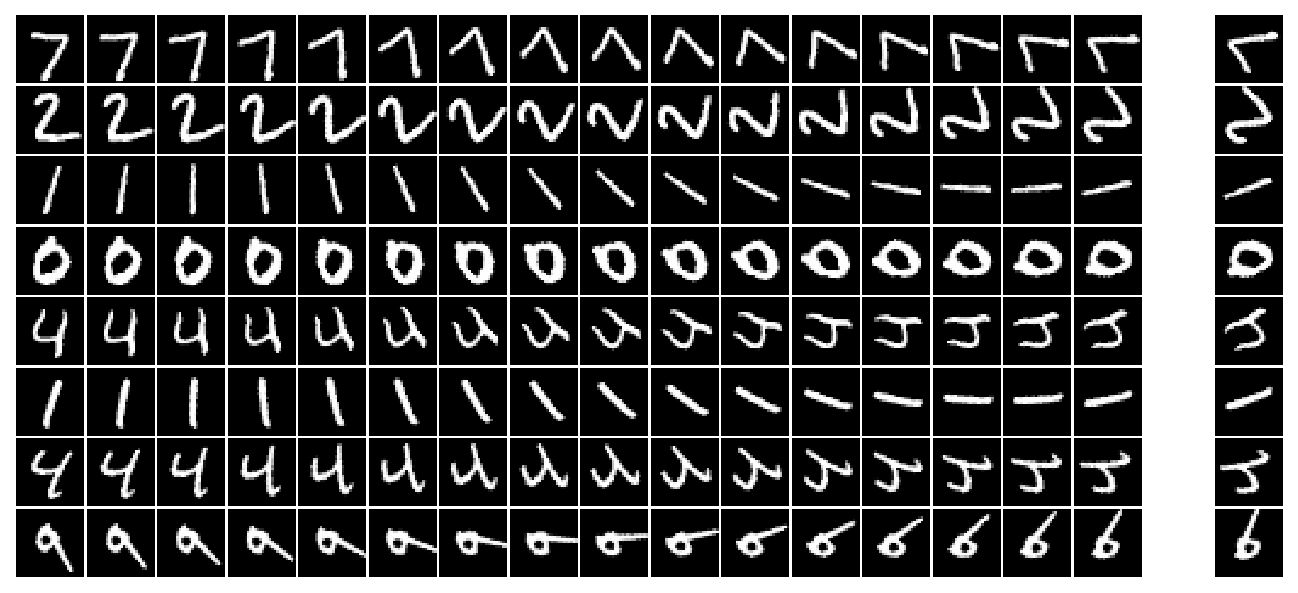

In [5]:
num = 8
x2p = np.concatenate([
    tonp(x[:num]),
    np_nans((num, 1, 28, 28)),
    tonp(y[:num]),
], axis=1)
x2p.shape

_ = plot_weights(x2p.reshape(-1, 28, 28), method='none', nrows=num)

In [6]:
delta =  tonp(x[:num, -1] - y[:num, 0])
delta.shape

(8, 28, 28)

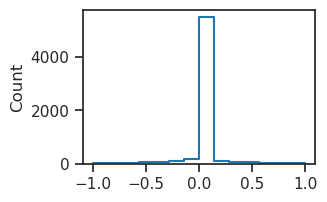

In [7]:
histplot(delta.ravel());

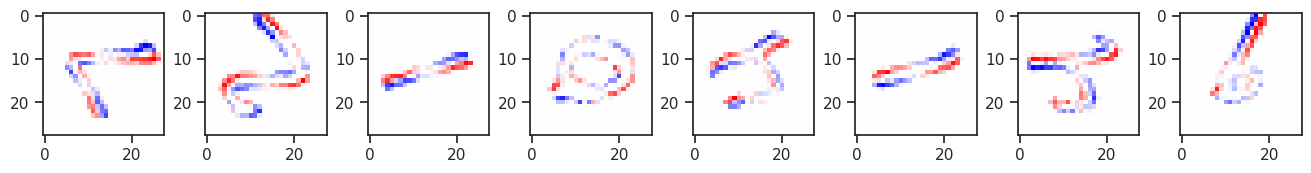

In [8]:
fig, axes = create_figure(1, num, (13, 2))

for i, ax in enumerate(axes.flat):
    ax.imshow(delta[i], cmap='bwr', vmin=-1, vmax=1)
plt.show()

## Dataset: EyeMovies

In [9]:
kwargs = dict(
    tau_context=100,
    tau_pred=1,
    shuffle=True,
)
dl_trn, dl_vld = make_dataloader('EyeMovies32', device, **kwargs)

In [10]:
x, y = next(iter(dl_vld))
x.shape, y.shape

(torch.Size([256, 100, 32, 32]), torch.Size([256, 1, 32, 32]))

(8, 20, 32, 32)

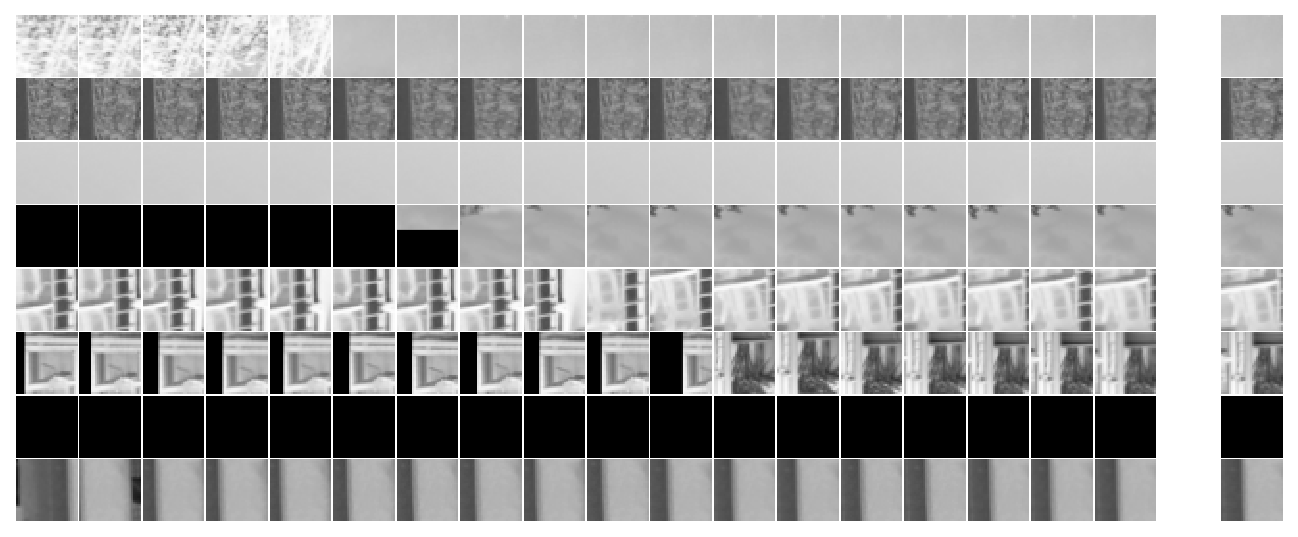

In [11]:
num = 8
x2p = np.concatenate([
    tonp(x[:num]),
    np_nans((num, 1, 32, 32)),
    tonp(y[:num]),
], axis=1)
x2p = x2p[:, -20:, ...]
print(x2p.shape)

_ = plot_weights(x2p.reshape(-1, 32, 32), method='none', nrows=num)

In [12]:
delta =  tonp(x[:num, -1] - y[:num, 0])
delta.shape

(8, 32, 32)

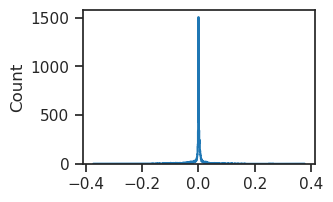

In [13]:
histplot(delta.ravel());

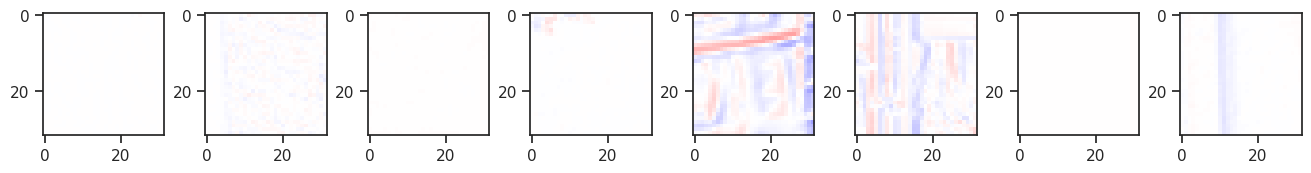

In [14]:
fig, axes = create_figure(1, num, (13, 2))

for i, ax in enumerate(axes.flat):
    ax.imshow(delta[i], cmap='bwr', vmin=-1, vmax=1)
plt.show()

## Fit a model

In [15]:
model_type = 'poisson'

cfg = CFG_CLASSES[model_type](dataset='EyeMovies16', n_latents=512)
vib = MODEL_CLASSES[model_type](cfg)

cfg_train = ConfigTrainVIB(batch_size=200, epochs=300, kl_beta=1.0)
tr = TrainerVIB(model=vib, cfg=cfg_train, device=device)

In [16]:
tr.model.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  PoissonVIB |  268.8 K   |
|     ———     |    ———     |
|    layer    |  137.7 K   |
|     dec     |  131.1 K   |
+-------------+------------+

In [17]:
print(tr.model.layer)

PoissonLayer(tau=[10,1], temp=1, beta=1)

In [18]:
print_num_params(tr.model.layer.enc.conv_t)
print_num_params(tr.model.layer.enc.conv_s)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    Conv2D   |   5.6 K    |
|     ———     |    ———     |
|    _layer   |   5.6 K    |
+-------------+------------+

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    Conv2D   |  131.6 K   |
|     ———     |    ———     |
|    _layer   |  131.6 K   |
+-------------+------------+

In [19]:
t_ker = tonp(tr.model.layer.enc.conv_t.weight)
s_ker = tonp(tr.model.layer.enc.conv_s.weight)

t_ker.shape, s_ker.shape

((512, 10, 1, 1), (512, 1, 16, 16))

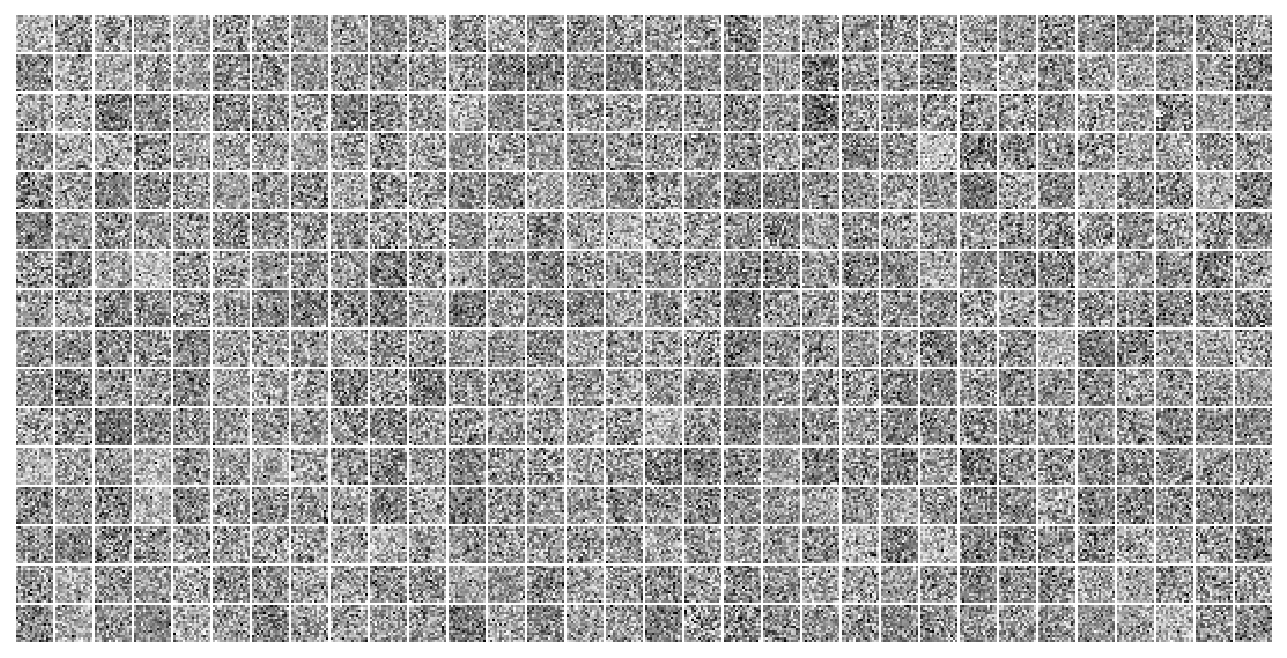

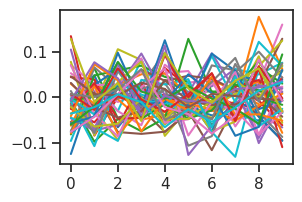

In [20]:
plot_weights(s_ker[:, 0, ...])
plt.plot(t_ker[:50, :, 0, 0].T)
plt.show()

## Fit

In [21]:
tr.train()

epoch # 300, avg loss: 7.671346: 100%|████████| 300/300 [33:48<00:00,  6.76s/it]


### Plot learned filters

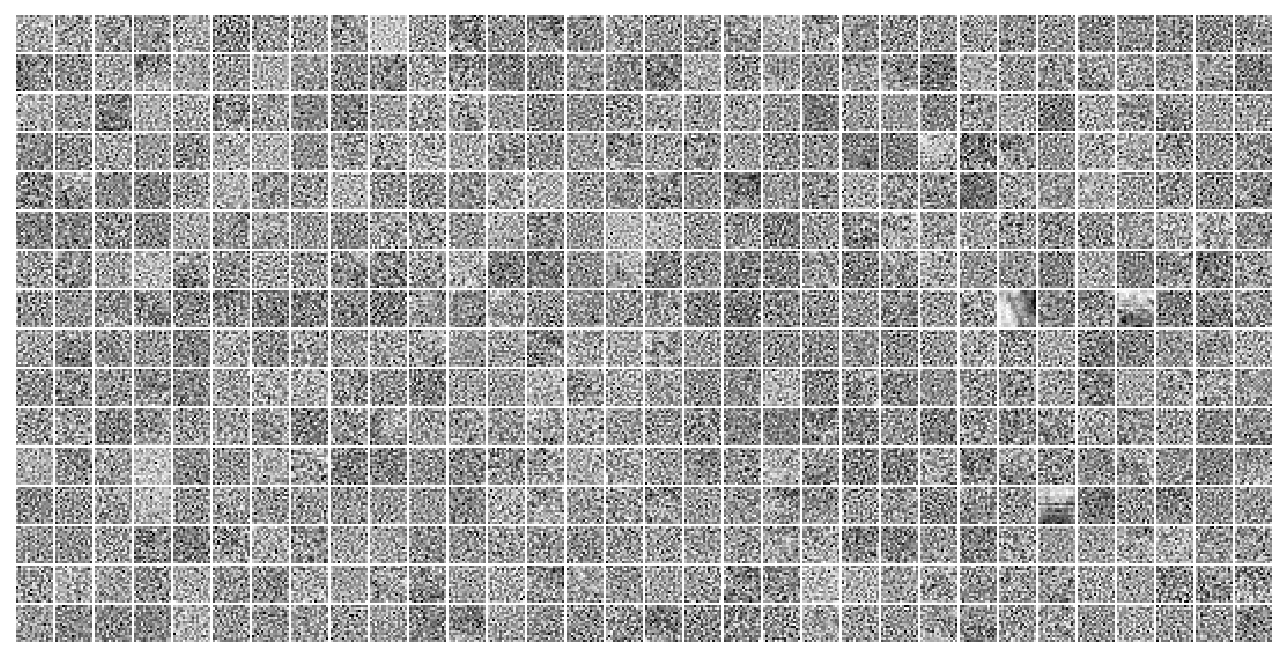

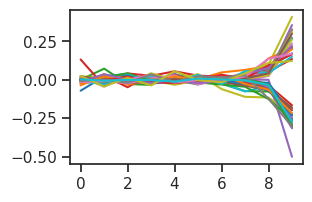

In [22]:
t_ker = tonp(tr.model.layer.enc.conv_t.weight)
s_ker = tonp(tr.model.layer.enc.conv_s.weight)

plot_weights(s_ker[:, 0, ...]);
plt.plot(t_ker[:50, :, 0, 0].T)
plt.show()

### Plot actual frames and preds

In [24]:
x, y, *_ = next(iter(tr.dl_vld))
output = tr.model(x, y.flatten(start_dim=1))

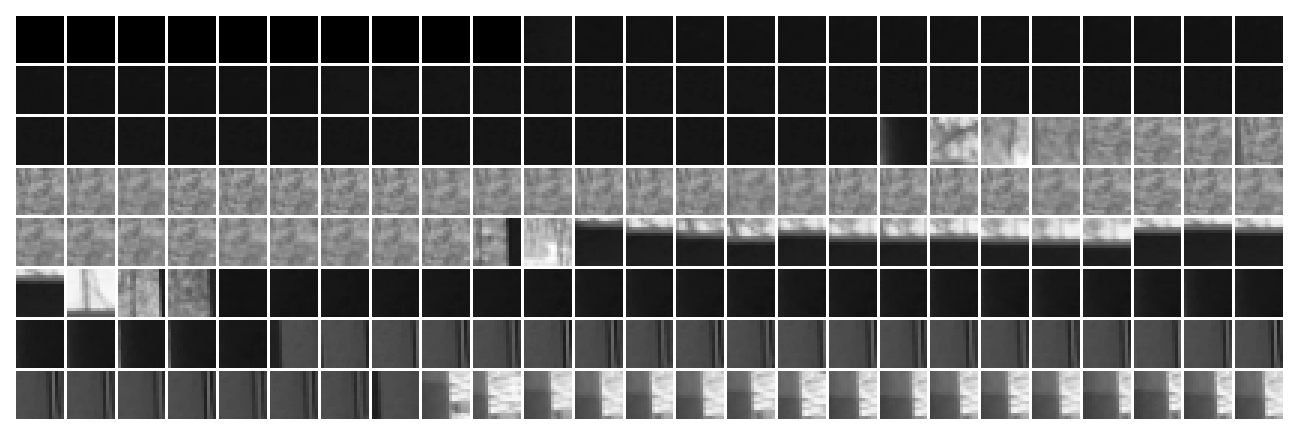

In [25]:
_ = plot_weights(y.squeeze(), method='none', nrows=8)

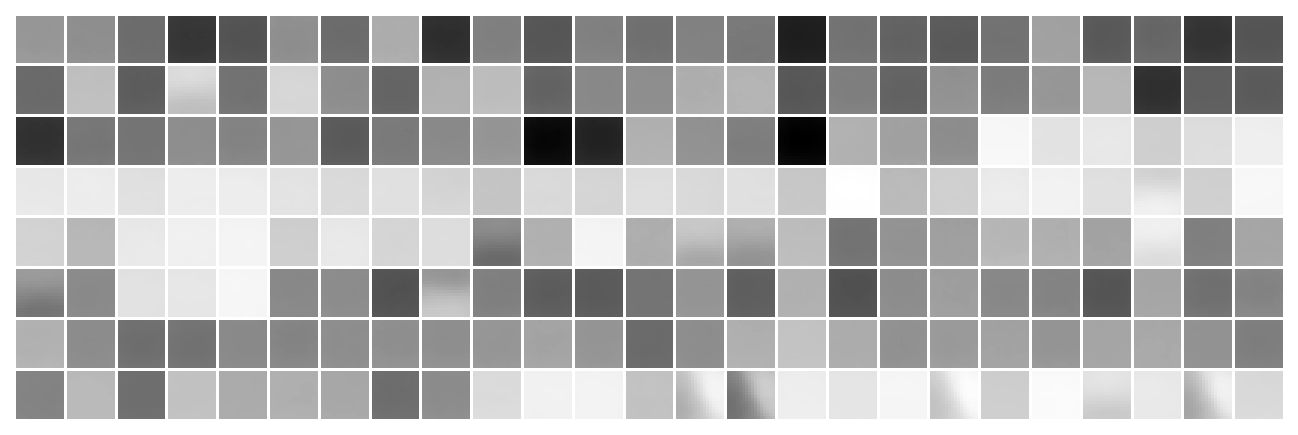

In [26]:
pred = output['conditional'].loc
shape = (-1, tr.model.cfg.npix, tr.model.cfg.npix)
_ = plot_weights(pred.reshape(shape), method='none', nrows=8)

In [27]:
print(tr.model.layer)

PoissonLayer(tau=[10,1], temp=0.05, beta=1)

### compute loss

In [28]:
data, loss, etc = tr.forward('vld')

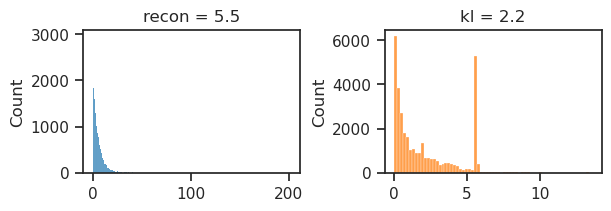

In [29]:
fig, axes = create_figure(1, 2)

sns.histplot(loss['recon'], ax=axes[0])
axes[0].set_title(f"recon = {loss['recon'].mean():0.1f}")

sns.histplot(loss['kl'], color='C1', ax=axes[1])
axes[1].set_title(f"kl = {loss['kl'].mean():0.1f}")

plt.show()